Khai báo thư viện ảnh

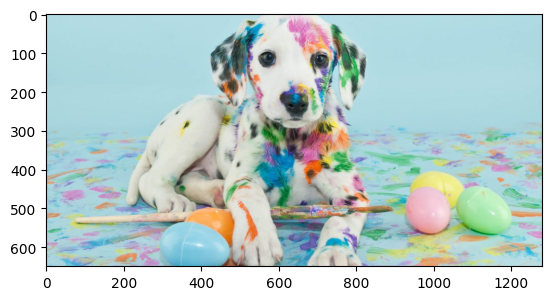

In [ ]:
import cv2
import matplotlib.pyplot as NguyenPhuocThanh
img = cv2.imread('hinh1.jpg')
# Đảo thứ tự kênh màu từ BGR sang RGB
img = img[:,:,::-1]
# Hiển thị ảnh
NguyenPhuocThanh.imshow(img)

1. Thực hành xử lý ảnh trong miền tần số:

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as NguyenPhuocThanh
# Đọc ảnh ở chế độ ảnh xám
img = cv2.imread('hinh1.jpg',0)
# Chuyển ảnh sang kiểu float32 để xử lý trong miền tần số
img_float32 = np.float32(img)
# Thực hiện biến đổi Fourier rời rạc (DFT)
dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)
# Dịch chuyển thành phần tần số thấp vào giữa phổ
dft_shift = np.fft.fftshift(dft)
# Tính phổ biên độ (magnitude spectrum) của ảnh trong miền tần số
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

2. Sử dụng đoạn code sau cho DFT, trình bày ý nghĩa của từng dòng lệnh.

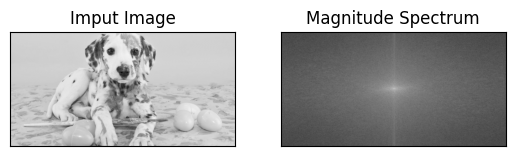

In [ ]:
# Tạo subplot thứ nhất và hiển thị ảnh gốc
NguyenPhuocThanh.subplot(121), NguyenPhuocThanh.imshow(img, cmap = 'gray')
# Đặt tiêu đề cho ảnh gốc và ẩn trục tọa độ
NguyenPhuocThanh.title('Imput Image'), NguyenPhuocThanh.xticks([]), NguyenPhuocThanh.yticks([])
# Tạo subplot thứ hai và hiển thị phổ biên độ
NguyenPhuocThanh.subplot(122), NguyenPhuocThanh.imshow(magnitude_spectrum, cmap = 'gray')
# Đặt tiêu đề cho phổ biên độ và ẩn trục tọa độ
NguyenPhuocThanh.title('Magnitude Spectrum'), NguyenPhuocThanh.xticks([]), NguyenPhuocThanh.yticks([])
# Hiển thị toàn bộ hình
NguyenPhuocThanh.show()

3. Sử dụng Fast Fourier Transform (FFT) Magnitude algorithm để phát hiện ảnh mờ

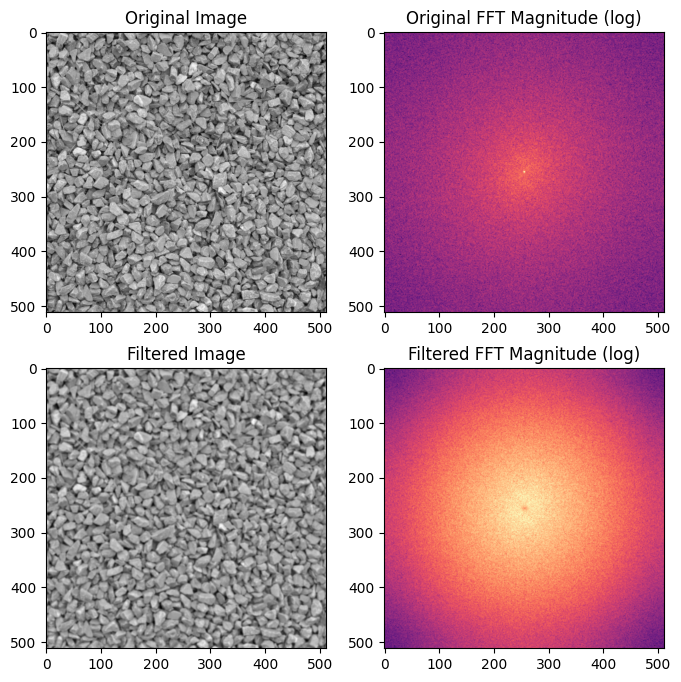

In [ ]:
import matplotlib.pyplot as NguyenPhuocThanh # Thư viện dùng để hiển thị đồ thị và hình ảnh
import numpy as np # Thư viện xử lý mảng số
from skimage.data import gravel # Tải ảnh mẫu gravel từ skimage
from skimage.filters import difference_of_gaussians, window # Các bộ lọc Difference of Gaussians và hàm window
from scipy.fft import fftn, fftshift # Thư viện dùng để thực hiện biến đổi Fourier nhanh

image = gravel() # Tải ảnh mẫu
# Nhân ảnh với cửa sổ Hann để cải thiện kết quả FFT
wimage = image * window('hann', image.shape) 
filtered_image = difference_of_gaussians(image, 1, 12) # Áp dụng bộ lọc Difference of Gaussians lên ảnh
filtered_wimage = filtered_image * window('hann', image.shape) # Áp dụng cửa sổ Hann cho ảnh đã lọc
im_f_mag = fftshift(np.abs(fftn(wimage))) # Tính phổ biên độ FFT của ảnh đã áp dụng cửa sổ
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage))) # Tính phổ biên độ FFT của ảnh đã lọc và áp dụng cửa sổ

# Tạo figure gồm 2 hàng 2 cột để hiển thị kết quả
fig, ax = NguyenPhuocThanh.subplots(nrows=2, ncols=2, figsize=(8, 8))
# Hiển thị ảnh gốc
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')
# Hiển thị phổ biên độ FFT của ảnh gốc (dạng log)
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')
# Hiển thị ảnh sau khi lọc
ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
# Hiển thị phổ biên độ FFT của ảnh đã lọc (dạng log)
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')
# Hiển thị toàn bộ kết quả
NguyenPhuocThanh.show()

Thực hành Harris Corner Detection

In [ ]:
import cv2 # Thư viện xử lý ảnh OpenCV
import numpy as np # Thư viện xử lý mảng số
from IPython.display import Image # Dùng để hiển thị ảnh trong môi trường Jupyter

# Hàm phát hiện góc trong ảnh bằng thuật toán Harris Corner Detection
def detect_corner(image_path, blockSize=2, ksize=3, k=0.04, threshold=0.01):    
    img = cv2.imread(image_path) # Đọc ảnh từ đường dẫn    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Chuyển ảnh sang ảnh xám    
    gray = np.float32(gray) # Chuyển ảnh xám sang kiểu float32 để xử lý    
    dst = cv2.cornerHarris(gray, blockSize, ksize, k) # Áp dụng thuật toán Harris để phát hiện góc    
    dst = cv2.dilate(dst, None) # Giãn kết quả để đánh dấu các góc rõ hơn    
    img[dst>threshold*dst.max()]=[0, 0, 255] # Áp dụng ngưỡng để xác định các điểm góc    
    cv2.imwrite('example.jpg',img) # Lưu ảnh kết quả    
    return img # Trả về ảnh kết quả

# Gọi hàm phát hiện góc
out_path = detect_corner('hinh1.jpg', blockSize=2, ksize=5, k=0.04, threshold=0.005)
Image(out_path) # Hiển thị ảnh kết quả

Thử lại

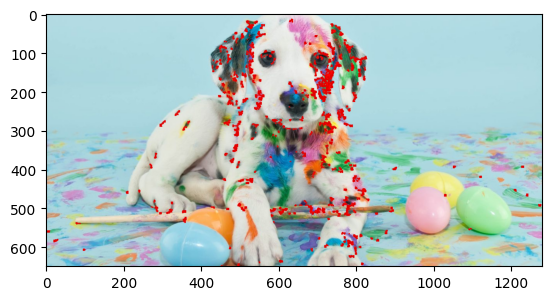

In [ ]:
import numpy as np  # Thư viện xử lý mảng số
import cv2  # Thư viện xử lý ảnh OpenCV
from matplotlib import pyplot as NguyenPhuocThanh  # Thư viện hiển thị ảnh và đồ thị
img = cv2.imread('example.jpg')  # Đọc ảnh từ file
NguyenPhuocThanh.imshow(img[:,:,::-1])  # Hiển thị ảnh (đổi BGR sang RGB)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)  # Chuyển ảnh sang ảnh xám
gray = np.float32(gray)  # Chuyển ảnh sang kiểu float32
dst = cv2.cornerHarris(gray,2,3,0.04)  # Áp dụng thuật toán Harris để phát hiện góc
dst = cv2.dilate(dst,None)  # Giãn kết quả để làm nổi bật các góc
img[dst>0.01*dst.max()] = [0,0,225]  # Đánh dấu các điểm góc bằng màu đỏ
NguyenPhuocThanh.imshow(img[:,:,::-1])  # Hiển thị ảnh sau khi đánh dấu góc

Band-pass filtering by Difference of Gaussians

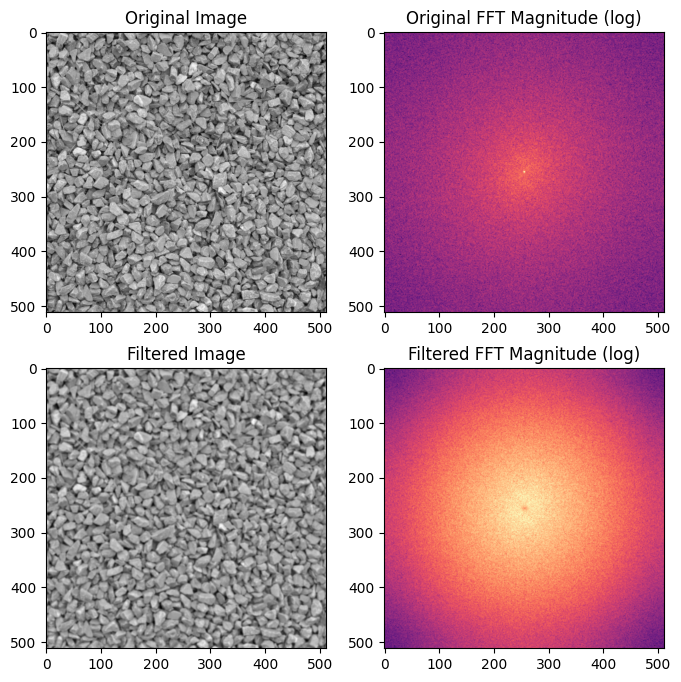

In [ ]:
import matplotlib.pyplot as NguyenPhuocThanh  # Thư viện hiển thị đồ thị và hình ảnh
import numpy as np  # Thư viện xử lý mảng số
from skimage.data import gravel  # Tải ảnh mẫu gravel từ skimage
from skimage.filters import difference_of_gaussians, window  # Bộ lọc Difference of Gaussians và hàm cửa sổ
from scipy.fft import fftn, fftshift  # Thư viện thực hiện biến đổi Fourier

image = gravel()  # Tải ảnh mẫu
wimage = image * window('hann', image.shape)  # Nhân ảnh với cửa sổ Hann để cải thiện FFT
filtered_image = difference_of_gaussians(image, 1, 12)  # Áp dụng bộ lọc Difference of Gaussians
filtered_wimage = filtered_image * window('hann', image.shape)  # Áp dụng cửa sổ Hann cho ảnh đã lọc
im_f_mag = fftshift(np.abs(fftn(wimage)))  # Tính phổ biên độ FFT của ảnh gốc
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))  # Tính phổ biên độ FFT của ảnh đã lọc
fig, ax = NguyenPhuocThanh.subplots(nrows=2, ncols=2, figsize=(8, 8))  # Tạo figure gồm 2x2 ô hiển thị
ax[0, 0].imshow(image, cmap='gray')  # Hiển thị ảnh gốc
ax[0, 0].set_title('Original Image')  # Tiêu đề ảnh gốc
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')  # Hiển thị phổ FFT của ảnh gốc (log)
ax[0, 1].set_title('Original FFT Magnitude (log)')  # Tiêu đề phổ FFT ảnh gốc
ax[1, 0].imshow(filtered_image, cmap='gray')  # Hiển thị ảnh sau khi lọc
ax[1, 0].set_title('Filtered Image')  # Tiêu đề ảnh đã lọc
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')  # Hiển thị phổ FFT của ảnh đã lọc (log)
ax[1, 1].set_title('Filtered FFT Magnitude (log)')  # Tiêu đề phổ FFT ảnh đã lọc
NguyenPhuocThanh.show()  # Hiển thị toàn bộ kết quả